# ResNet50 baseline for MURA

Train uses `train/` with an internal 10% validation split by study. The original `valid/` folder is kept as the final test dataset.

In [2]:
from pathlib import Path
import os
import random
import time

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from tqdm.auto import tqdm
from IPython.display import display, clear_output

SEED = 42
DATA_ROOT = Path("MURA-v1.1-resized-224x224")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "valid"
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = MODEL_DIR / "resnet50_mura_best.pt"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0  # In notebooks this is usually more stable; increase on Linux if needed.
EPOCHS = 8
LR = 3e-4
WEIGHT_DECAY = 1e-4
USE_PRETRAINED = True
FREEZE_BACKBONE_EPOCHS = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


/home/rubar01/Course 1/Project/Project2025/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp"}


def label_from_path(path: Path) -> int:
    study_name = path.parent.name.lower()
    if "positive" in study_name:
        return 1
    if "negative" in study_name:
        return 0
    raise ValueError(f"Cannot infer label from study folder: {path.parent}")


def study_from_path(path: Path) -> str:
    # Example: train/XR_HAND/patient10502/study1_positive/image1.png
    return str(path.parent)


def anatomy_from_path(path: Path) -> str:
    return path.parts[-4]


def build_mura_frame(split_dir: Path) -> pd.DataFrame:
    if not split_dir.exists():
        raise FileNotFoundError(f"Missing split directory: {split_dir.resolve()}")

    rows = []
    for path in sorted(split_dir.rglob("*")):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            rows.append(
                {
                    "path": path,
                    "label": label_from_path(path),
                    "study": study_from_path(path),
                    "anatomy": anatomy_from_path(path),
                }
            )

    if not rows:
        raise RuntimeError(f"No images found under {split_dir.resolve()}")

    return pd.DataFrame(rows)


train_full_df = build_mura_frame(TRAIN_DIR)
test_df = build_mura_frame(TEST_DIR)

print("train images:", len(train_full_df), "studies:", train_full_df.study.nunique())
print("test images:", len(test_df), "studies:", test_df.study.nunique())
display(train_full_df.groupby(["anatomy", "label"]).size().unstack(fill_value=0))
display(test_df.groupby(["anatomy", "label"]).size().unstack(fill_value=0))

train images: 36808 studies: 13457
test images: 3197 studies: 1199


label,0,1
anatomy,,
XR_ELBOW,2925,2006
XR_FINGER,3138,1968
XR_FOREARM,1164,661
XR_HAND,4059,1484
XR_HUMERUS,673,599
XR_SHOULDER,4211,4168
XR_WRIST,5765,3987


label,0,1
anatomy,,
XR_ELBOW,235,230
XR_FINGER,214,247
XR_FOREARM,150,151
XR_HAND,271,189
XR_HUMERUS,148,140
XR_SHOULDER,285,278
XR_WRIST,364,295


In [4]:
display(train_full_df.sample(5))
display(test_df.sample(5))

,path,label,study,anatomy
263,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
14766,MURA-v1.1-resized-224x224/train/XR_HAND/patien...,0,MURA-v1.1-resized-224x224/train/XR_HAND/patien...,XR_HAND
5100,MURA-v1.1-resized-224x224/train/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/train/XR_FINGER/pati...,XR_FINGER
36540,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
24129,MURA-v1.1-resized-224x224/train/XR_SHOULDER/pa...,0,MURA-v1.1-resized-224x224/train/XR_SHOULDER/pa...,XR_SHOULDER


,path,label,study,anatomy
729,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,XR_FINGER
1315,MURA-v1.1-resized-224x224/valid/XR_HAND/patien...,0,MURA-v1.1-resized-224x224/valid/XR_HAND/patien...,XR_HAND
1938,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,0,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,XR_HUMERUS
726,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,1,MURA-v1.1-resized-224x224/valid/XR_FINGER/pati...,XR_FINGER
1933,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,0,MURA-v1.1-resized-224x224/valid/XR_HUMERUS/pat...,XR_HUMERUS


In [5]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
train_idx, internal_val_idx = next(
    splitter.split(train_full_df, y=train_full_df["label"], groups=train_full_df["study"])
)

train_df = train_full_df.iloc[train_idx].reset_index(drop=True)
internal_val_df = train_full_df.iloc[internal_val_idx].reset_index(drop=True)

print("fit train images:", len(train_df), "studies:", train_df.study.nunique())
print("internal val images:", len(internal_val_df), "studies:", internal_val_df.study.nunique())
print("study leakage:", len(set(train_df.study) & set(internal_val_df.study)))

display(pd.DataFrame({
    "train": train_df.label.value_counts(normalize=True).sort_index(),
    "internal_val": internal_val_df.label.value_counts(normalize=True).sort_index(),
    "test": test_df.label.value_counts(normalize=True).sort_index(),
}).rename(index={0: "negative", 1: "positive"}))

fit train images: 33143 studies: 12111
internal val images: 3665 studies: 1346
study leakage: 0


,train,internal_val,test
label,,,
negative,0.592946,0.62292,0.521426
positive,0.407054,0.37708,0.478574


In [6]:
train_tfms = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.90, 1.10)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=7),
        transforms.RandomAffine(degrees=0, translate=(0.04, 0.04), scale=(0.95, 1.05)),
        transforms.ColorJitter(brightness=0.12, contrast=0.18),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet50_Weights.DEFAULT.transforms().mean, std=ResNet50_Weights.DEFAULT.transforms().std),
    ]
)

eval_tfms = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=ResNet50_Weights.DEFAULT.transforms().mean, std=ResNet50_Weights.DEFAULT.transforms().std),
    ]
)


class MuraImageDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row.path).convert("L")
        if self.transform is not None:
            image = self.transform(image)
        label = torch.tensor(row.label, dtype=torch.float32)
        return image, label


train_ds = MuraImageDataset(train_df, train_tfms)
internal_val_ds = MuraImageDataset(internal_val_df, eval_tfms)
test_ds = MuraImageDataset(test_df, eval_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
internal_val_loader = DataLoader(internal_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

xb, yb = next(iter(train_loader))
print(xb.shape, yb.shape, yb[:8].tolist())

torch.Size([32, 3, 224, 224]) torch.Size([32]) [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


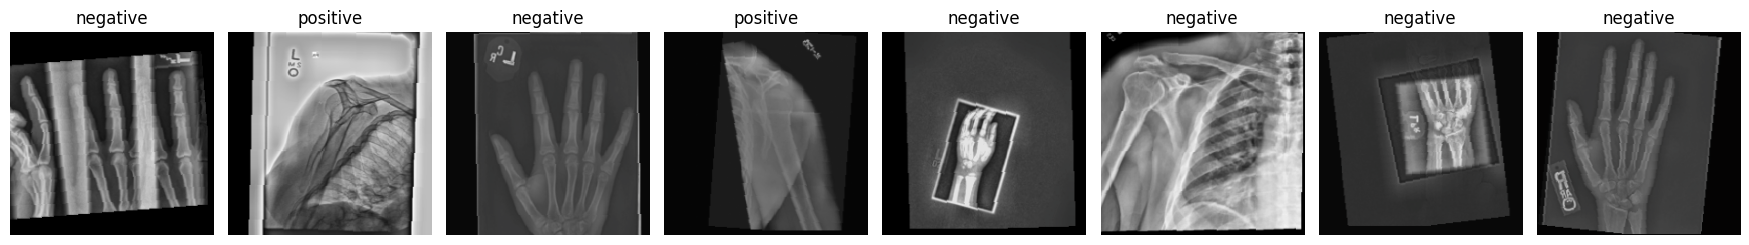

In [7]:
def show_batch(loader, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]

    mean = torch.tensor(ResNet50_Weights.DEFAULT.transforms().mean).view(3, 1, 1)
    std = torch.tensor(ResNet50_Weights.DEFAULT.transforms().std).view(3, 1, 1)

    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.4))
    if n == 1:
        axes = [axes]
    for ax, image, label in zip(axes, images, labels):
        image = (image.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
        ax.imshow(image)
        ax.set_title("positive" if int(label.item()) == 1 else "negative")
        ax.axis("off")
    plt.tight_layout()


show_batch(train_loader)

In [8]:
def build_model(use_pretrained: bool = True) -> nn.Module:
    weights = ResNet50_Weights.DEFAULT if use_pretrained else None
    try:
        model = models.resnet50(weights=weights)
    except Exception as exc:
        print(f"Could not load pretrained ResNet50 weights ({exc}); using random initialization.")
        model = models.resnet50(weights=None)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model


model = build_model(USE_PRETRAINED).to(device)

pos_count = train_df.label.sum()
neg_count = len(train_df) - pos_count
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

print("pos_weight:", round(float(pos_weight.item()), 3))

pos_weight: 1.457


In [9]:
def set_backbone_trainable(model: nn.Module, trainable: bool) -> None:
    for name, param in model.named_parameters():
        if not name.startswith("fc."):
            param.requires_grad = trainable


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob = np.asarray(y_prob, dtype=np.float32)
    y_pred = (y_prob >= threshold).astype(np.int64)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
    }
    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    else:
        metrics["roc_auc"] = np.nan
    return metrics


def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    all_targets = []
    all_probs = []

    with torch.set_grad_enabled(is_train):
        for images, targets in tqdm(loader, leave=False):
            images = images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            logits = model(images).squeeze(1)
            loss = criterion(logits, targets)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            all_targets.extend(targets.detach().cpu().numpy().tolist())
            all_probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    metrics = binary_metrics(all_targets, all_probs)
    metrics["loss"] = avg_loss
    return metrics


def format_metrics(prefix, metrics):
    return (
        f"{prefix} loss={metrics['loss']:.4f} "
        f"acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
        f"auc={metrics['roc_auc']:.4f} kappa={metrics['kappa']:.4f}"
    )

,epoch,lr,train_accuracy,train_precision,train_recall,train_f1,train_kappa,train_roc_auc,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_kappa,val_roc_auc,val_loss
0,1,0.000300,0.632562,0.540698,0.646505,0.588887,0.261475,0.681222,0.770437,0.685948,0.590023,0.547757,0.568105,0.321909,0.723036,0.729221
1,2,0.000090,0.755635,0.705645,0.685716,0.695538,0.491526,0.815279,0.615263,0.807367,0.842799,0.601302,0.701858,0.565377,0.841945,0.566669
2,3,0.000090,0.795824,0.763232,0.722556,0.742337,0.573469,0.858955,0.545512,0.820191,0.780886,0.727207,0.753091,0.611987,0.868256,0.523479
3,4,0.000090,0.808466,0.778958,0.739234,0.758576,0.600024,0.871874,0.520293,0.843111,0.843404,0.717077,0.775127,0.655866,0.879520,0.505352
4,5,0.000090,0.820173,0.793058,0.755318,0.773728,0.624674,0.885268,0.494683,0.833834,0.864279,0.663531,0.750716,0.629299,0.873182,0.527008
5,6,0.000045,0.830371,0.804551,0.770440,0.787126,0.646249,0.896782,0.471705,0.813643,0.742877,0.773517,0.757887,0.606513,0.867740,0.531886
6,7,0.000045,0.848686,0.824950,0.797495,0.810990,0.684896,0.916730,0.425957,0.847476,0.859389,0.712012,0.778789,0.663959,0.883241,0.523031
7,8,0.000045,0.861570,0.839110,0.816470,0.827635,0.712012,0.929375,0.394106,0.839836,0.810304,0.751085,0.779572,0.654079,0.881891,0.526534


epoch 08/8 (331.1s) | train loss=0.3941 acc=0.8616 f1=0.8276 auc=0.9294 kappa=0.7120 | internal_val loss=0.5265 acc=0.8398 f1=0.7796 auc=0.8819 kappa=0.6541


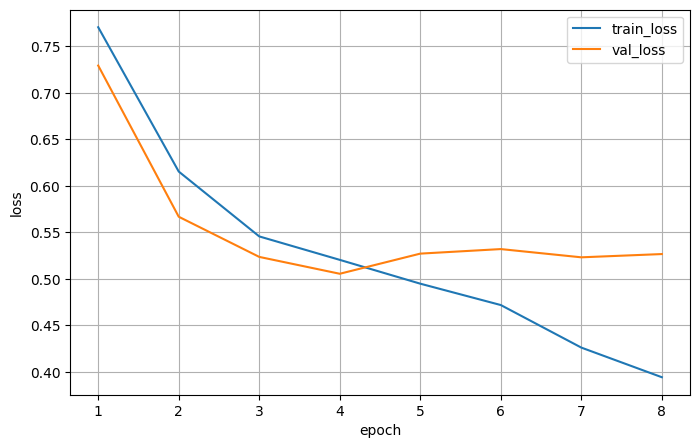

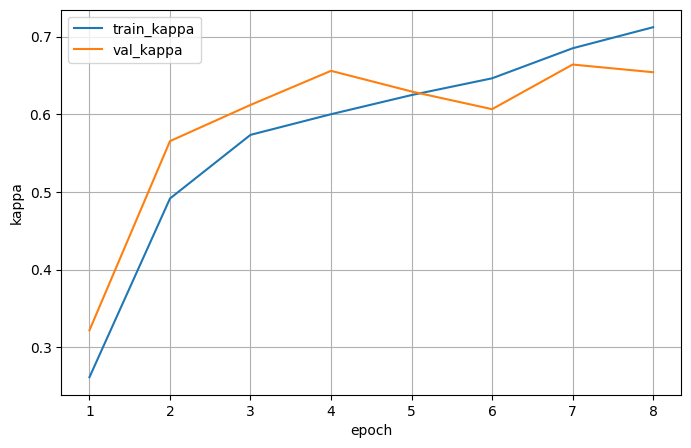

,epoch,lr,train_accuracy,train_precision,train_recall,train_f1,train_kappa,train_roc_auc,train_loss,val_accuracy,val_precision,val_recall,val_f1,val_kappa,val_roc_auc,val_loss
0,1,0.000300,0.632562,0.540698,0.646505,0.588887,0.261475,0.681222,0.770437,0.685948,0.590023,0.547757,0.568105,0.321909,0.723036,0.729221
1,2,0.000090,0.755635,0.705645,0.685716,0.695538,0.491526,0.815279,0.615263,0.807367,0.842799,0.601302,0.701858,0.565377,0.841945,0.566669
2,3,0.000090,0.795824,0.763232,0.722556,0.742337,0.573469,0.858955,0.545512,0.820191,0.780886,0.727207,0.753091,0.611987,0.868256,0.523479
3,4,0.000090,0.808466,0.778958,0.739234,0.758576,0.600024,0.871874,0.520293,0.843111,0.843404,0.717077,0.775127,0.655866,0.879520,0.505352
4,5,0.000090,0.820173,0.793058,0.755318,0.773728,0.624674,0.885268,0.494683,0.833834,0.864279,0.663531,0.750716,0.629299,0.873182,0.527008
5,6,0.000045,0.830371,0.804551,0.770440,0.787126,0.646249,0.896782,0.471705,0.813643,0.742877,0.773517,0.757887,0.606513,0.867740,0.531886
6,7,0.000045,0.848686,0.824950,0.797495,0.810990,0.684896,0.916730,0.425957,0.847476,0.859389,0.712012,0.778789,0.663959,0.883241,0.523031
7,8,0.000045,0.861570,0.839110,0.816470,0.827635,0.712012,0.929375,0.394106,0.839836,0.810304,0.751085,0.779572,0.654079,0.881891,0.526534


In [34]:
history = []
best_val_kappa = -1.0

for epoch in range(1, EPOCHS + 1):
    start = time.time()

    if epoch <= FREEZE_BACKBONE_EPOCHS:
        set_backbone_trainable(model, False)
    elif epoch == FREEZE_BACKBONE_EPOCHS + 1:
        set_backbone_trainable(model, True)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LR * 0.3, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    train_metrics = run_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_epoch(model, internal_val_loader, criterion, optimizer=None)
    scheduler.step(val_metrics["kappa"])

    row = {"epoch": epoch, "lr": optimizer.param_groups[0]["lr"]}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    history.append(row)

    history_df = pd.DataFrame(history)
    clear_output(wait=True)
    display(history_df)


    if val_metrics["kappa"] > best_val_kappa:
        best_val_kappa = val_metrics["kappa"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "best_val_kappa": best_val_kappa,
                "config": {
                    "data_root": str(DATA_ROOT),
                    "img_size": IMG_SIZE,
                    "use_pretrained": USE_PRETRAINED,
                },
            },
            BEST_MODEL_PATH,
        )

    elapsed = time.time() - start
    print(
        f"epoch {epoch:02d}/{EPOCHS} ({elapsed:.1f}s) | "
        + format_metrics("train", train_metrics)
        + " | "
        + format_metrics("internal_val", val_metrics)
    )
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_kappa"], label="train_kappa")
    plt.plot(history_df["epoch"], history_df["val_kappa"], label="val_kappa")
    plt.xlabel("epoch")
    plt.ylabel("kappa")
    plt.legend()
    plt.grid(True)
    plt.show()

history_df = pd.DataFrame(history)
display(history_df)

In [10]:
if BEST_MODEL_PATH.exists():
    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"loaded best checkpoint from epoch {checkpoint['epoch']} with val_kappa={checkpoint['best_val_kappa']:.4f}")

test_metrics = run_epoch(model, test_loader, criterion, optimizer=None)
print(format_metrics("test", test_metrics))

loaded best checkpoint from epoch 7 with val_kappa=0.6640


test loss=0.5836 acc=0.8201 f1=0.7895 auc=0.8855 kappa=0.6364


In [11]:
if "history_df" in globals() and not history_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df.epoch, history_df.train_loss, label="train")
    axes[0].plot(history_df.epoch, history_df.val_loss, label="internal_val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history_df.epoch, history_df.train_f1, label="train_f1")
    axes[1].plot(history_df.epoch, history_df.val_f1, label="internal_val_f1")
    axes[1].plot(history_df.epoch, history_df.val_roc_auc, label="internal_val_auc")
    axes[1].set_title("Validation metrics")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    plt.tight_layout()

In [1]:
history_df.to_csv(MODEL_DIR / "resnet_50_training_history.csv", index=False)

NameError: name 'history_df' is not defined

## Cohen's kappa на уровне исследований

Вероятности по снимкам усредняются внутри каждого `study`, затем Cohen's kappa считается по исследованиям для train, internal_val и test.


In [12]:
def predict_study_level(model, frame: pd.DataFrame, threshold: float = 0.5, batch_size: int = BATCH_SIZE):
    eval_ds = MuraImageDataset(frame, eval_tfms)
    eval_loader = DataLoader(
        eval_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    probs = []
    with torch.no_grad():
        for images, _ in tqdm(eval_loader, leave=False):
            images = images.to(device, non_blocking=True)
            logits = model(images).squeeze(1)
            probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())

    image_predictions = frame.reset_index(drop=True).copy()
    image_predictions["prob"] = probs
    image_predictions["pred"] = (image_predictions["prob"] >= threshold).astype(int)

    study_predictions = (
        image_predictions
        .groupby("study", as_index=False)
        .agg(
            label=("label", "first"),
            anatomy=("anatomy", "first"),
            n_images=("path", "size"),
            prob=("prob", "mean"),
        )
    )
    study_predictions["pred"] = (study_predictions["prob"] >= threshold).astype(int)
    return study_predictions


study_level_predictions = {
    "train": predict_study_level(model, train_df),
    "internal_val": predict_study_level(model, internal_val_df),
    "test": predict_study_level(model, test_df),
}


# Подбор порогов

In [17]:
best_threshold_kappa = -1.0
best_threshold = None
threshold_kappas = []
thresholds = np.linspace(0.4, 0.6, num=11)
for threshold in thresholds:
    print(f"Internal val study-level metrics at threshold {threshold}:")
    study_level_pred_val = predict_study_level(model, internal_val_df, threshold=threshold)
    cohen_kappa = cohen_kappa_score(study_level_pred_val["label"], study_level_pred_val["pred"])
    threshold_kappas.append({"threshold": threshold, "kappa": cohen_kappa})
    print(f"  Cohen's kappa: {cohen_kappa:.4f}")
    if cohen_kappa > best_threshold_kappa:
        best_threshold_kappa = cohen_kappa
        best_threshold = threshold
print(f"Best threshold based on internal val kappa: {best_threshold} (kappa={best_threshold_kappa:.4f})")
# plot threshold vs kappa using plotly express
from plotly import express as px
threshold_kappa_df = pd.DataFrame(threshold_kappas)
fig = px.line(threshold_kappa_df, x="threshold", y="kappa", title="Cohen's kappa vs classification threshold")
fig.show()

Internal val study-level metrics at threshold 0.4:


  Cohen's kappa: 0.6985
Internal val study-level metrics at threshold 0.42000000000000004:


  Cohen's kappa: 0.7060
Internal val study-level metrics at threshold 0.44:


  Cohen's kappa: 0.7098
Internal val study-level metrics at threshold 0.46:


  Cohen's kappa: 0.7102
Internal val study-level metrics at threshold 0.48:


...

  Cohen's kappa: 0.6987
Internal val study-level metrics at threshold 0.54:


  Cohen's kappa: 0.6853
Internal val study-level metrics at threshold 0.56:


  Cohen's kappa: 0.6829
Internal val study-level metrics at threshold 0.58:


  Cohen's kappa: 0.6801
Internal val study-level metrics at threshold 0.6:


  Cohen's kappa: 0.6702
Best threshold based on internal val kappa: 0.48 (kappa=0.7107)


In [18]:
study_level_predictions = {
    "train": predict_study_level(model, train_df, threshold=best_threshold),
    "internal_val": predict_study_level(model, internal_val_df, threshold=best_threshold),
    "test": predict_study_level(model, test_df, threshold=best_threshold),
}


In [22]:
study_kappa_rows = []
for split_name, study_pred in study_level_predictions.items():
    study_kappa_rows.append(
        {
            "split": split_name,
            "anatomy": "all",
            "studies": len(study_pred),
            "positive_studies": int(study_pred["label"].sum()),
            "negative_studies": int((study_pred["label"] == 0).sum()),
            "cohen_kappa_by_study": cohen_kappa_score(study_pred["label"], study_pred["pred"]),
            "accuracy_by_study": accuracy_score(study_pred["label"], study_pred["pred"]),
        }
    )
    for anatomy in study_pred["anatomy"].unique():
        anatomy_pred = study_pred[study_pred["anatomy"] == anatomy]
        study_kappa_rows.append(
            {
                "split": split_name,
                "anatomy": anatomy,
                "studies": len(anatomy_pred),
                "positive_studies": int(anatomy_pred["label"].sum()),
                "negative_studies": int((anatomy_pred["label"] == 0).sum()),
                "cohen_kappa_by_study": cohen_kappa_score(anatomy_pred["label"], anatomy_pred["pred"]),
                "accuracy_by_study": accuracy_score(anatomy_pred["label"], anatomy_pred["pred"]),
            }
        )

study_kappa_df = pd.DataFrame(study_kappa_rows)
display(study_kappa_df)

study_kappa_df.to_csv(MODEL_DIR / "resnet_50_study_level_kappa.csv", index=False)
for split_name, study_pred in study_level_predictions.items():
    study_pred.to_csv(MODEL_DIR / f"resnet_50_{split_name}_study_predictions.csv", index=False)


,split,anatomy,studies,positive_studies,negative_studies,cohen_kappa_by_study,accuracy_by_study
0,train,all,12111,4691,7420,0.756353,0.888283
1,train,XR_ELBOW,1572,595,977,0.744004,0.885496
2,train,XR_FINGER,1751,595,1156,0.785297,0.906339
3,train,XR_FOREARM,772,251,521,0.782105,0.908031
4,train,XR_HAND,1836,478,1358,0.642735,0.878540
5,train,XR_HUMERUS,523,243,280,0.821851,0.912046
6,train,XR_SHOULDER,2546,1323,1223,0.731527,0.865279
7,train,XR_WRIST,3111,1206,1905,0.770842,0.895211
8,internal_val,all,1346,486,860,0.710692,0.871471
9,internal_val,XR_ELBOW,182,65,117,0.719490,0.879121


In [23]:
study_kappa_df[study_kappa_df['split'] == 'test']

,split,anatomy,studies,positive_studies,negative_studies,cohen_kappa_by_study,accuracy_by_study
16,test,all,1199,538,661,0.683909,0.846539
17,test,XR_ELBOW,158,66,92,0.703615,0.860759
18,test,XR_FINGER,175,83,92,0.687851,0.845714
19,test,XR_FOREARM,133,64,69,0.681055,0.842105
20,test,XR_HAND,167,66,101,0.557598,0.802395
21,test,XR_HUMERUS,135,67,68,0.792536,0.896296
22,test,XR_SHOULDER,194,95,99,0.648588,0.824742
23,test,XR_WRIST,237,97,140,0.700173,0.860759


,path,label,study,anatomy
0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
1,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
2,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,0,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
3,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,1,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
4,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,1,MURA-v1.1-resized-224x224/train/XR_ELBOW/patie...,XR_ELBOW
...,...,...,...,...
33138,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
33139,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
33140,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
33141,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,0,MURA-v1.1-resized-224x224/train/XR_WRIST/patie...,XR_WRIST
